In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [4]:
from src.preprocessing import FraudDetectionPipeline
import joblib


2026-06-13 15:45:33,342 - INFO - Processed data loaded: (151112, 12)
2026-06-13 15:45:33,534 - INFO - transaction_frequency — min=1, max=1, mean=1.00, nunique=1
2026-06-13 15:45:33,537 - INFO - Applying Target Encoding to 'country'...
2026-06-13 15:45:33,831 - INFO - Ran Feature Engineering.......
2026-06-13 15:45:34,115 - WARNING - Skipping scaling for zero-variance columns (will keep raw values): ['transaction_frequency']
2026-06-13 15:45:34,193 - INFO - Standard Scaling done....
2026-06-13 15:45:34,531 - INFO - One Hot Encoging done....
2026-06-13 15:45:34,546 - INFO - Categorical features detected → Using SMOTENC


Training shape before SMOTE: (120889, 18)
Training shape after  SMOTE: (164352, 18)


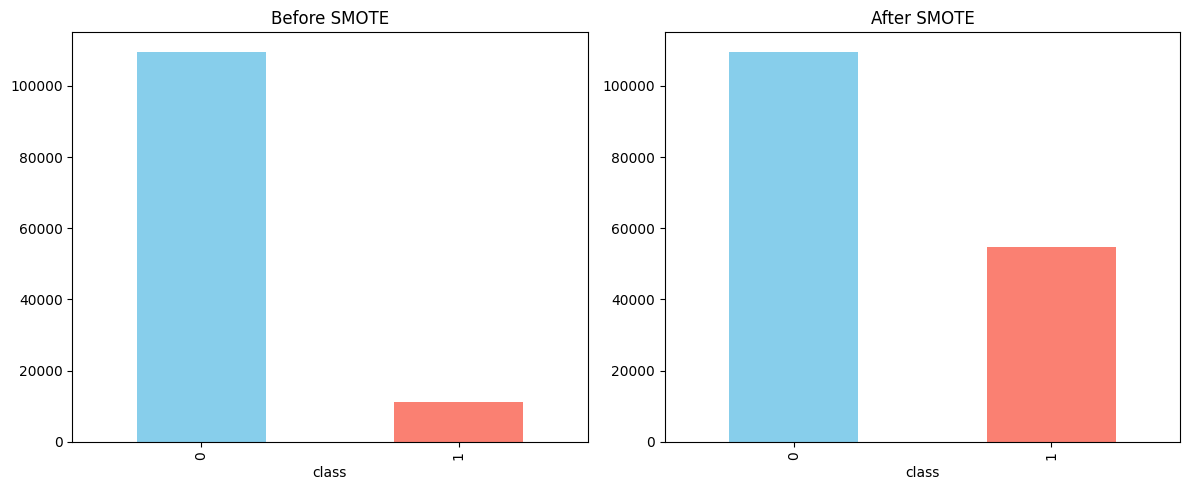

In [5]:
fraud_preprocessing=FraudDetectionPipeline('../data/processed/processedData.csv', is_fraud=True)
X_train, y_train, X_test, y_test=fraud_preprocessing.run()

In [7]:
from src.model_train import ModelTrain

2026-06-13 15:46:11,226 - INFO - Training Baseline Logistic Regression...


The AUC ROC score:  0.751120266339225
The Average Precision Score:  0.39885212244189233
The F1 Score is  0.28251728315872
THe True Negative: 18174 
 The False Postives: 9219 
 The False Negatives: 848 
 The true Positives: 1982
              precision    recall  f1-score   support

   Not Fraud       0.96      0.66      0.78     27393
       Fraud       0.18      0.70      0.28      2830

    accuracy                           0.67     30223
   macro avg       0.57      0.68      0.53     30223
weighted avg       0.88      0.67      0.74     30223



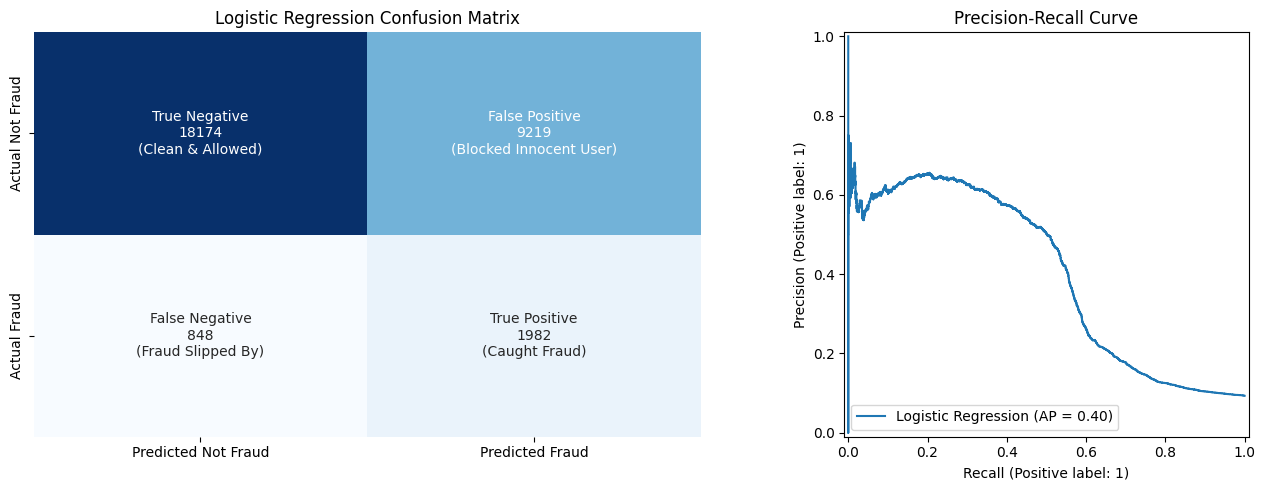

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [8]:
mt=ModelTrain(X_train, y_train, X_test, y_test)
mt.train_log_reg(n_iter=5000)

2026-06-13 15:46:13,748 - INFO - Starting Hyperparameter Tuning for Random_Forest...
2026-06-13 15:54:45,899 - INFO - Best parameters for Random_Forest: {'max_depth': 15, 'n_estimators': 200}



PERFORMANCE METRICS FOR: RANDOM_FOREST
The Average Precision Score:   0.6162
The F1 Score:                  0.6712
Recall (Fraud Class):          0.5269
THe True Negative (True Non-Frauds): 27271 
 The False Postives (Non-Frauds being passed as Frauds): 122 
 The False Negatives (Frauds being passed as Non-Fruads): 1339 
 The true Positives (True Fruads caught): 1491
              precision    recall  f1-score   support

   Not Fraud       0.95      1.00      0.97     27393
       Fraud       0.92      0.53      0.67      2830

    accuracy                           0.95     30223
   macro avg       0.94      0.76      0.82     30223
weighted avg       0.95      0.95      0.95     30223

--------------------------------------------------


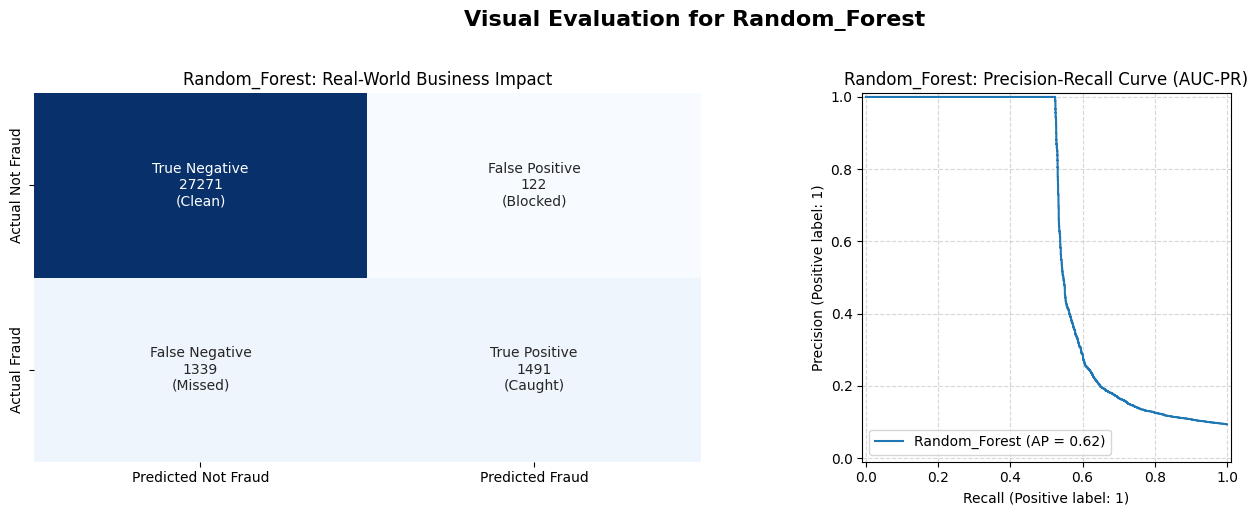

2026-06-13 15:54:50,415 - INFO - Starting Hyperparameter Tuning for XGBoost...
2026-06-13 15:56:09,976 - INFO - Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}



PERFORMANCE METRICS FOR: XGBOOST
The Average Precision Score:   0.6087
The F1 Score:                  0.6698
Recall (Fraud Class):          0.5251
THe True Negative (True Non-Frauds): 27272 
 The False Postives (Non-Frauds being passed as Frauds): 121 
 The False Negatives (Frauds being passed as Non-Fruads): 1344 
 The true Positives (True Fruads caught): 1486
              precision    recall  f1-score   support

   Not Fraud       0.95      1.00      0.97     27393
       Fraud       0.92      0.53      0.67      2830

    accuracy                           0.95     30223
   macro avg       0.94      0.76      0.82     30223
weighted avg       0.95      0.95      0.95     30223

--------------------------------------------------


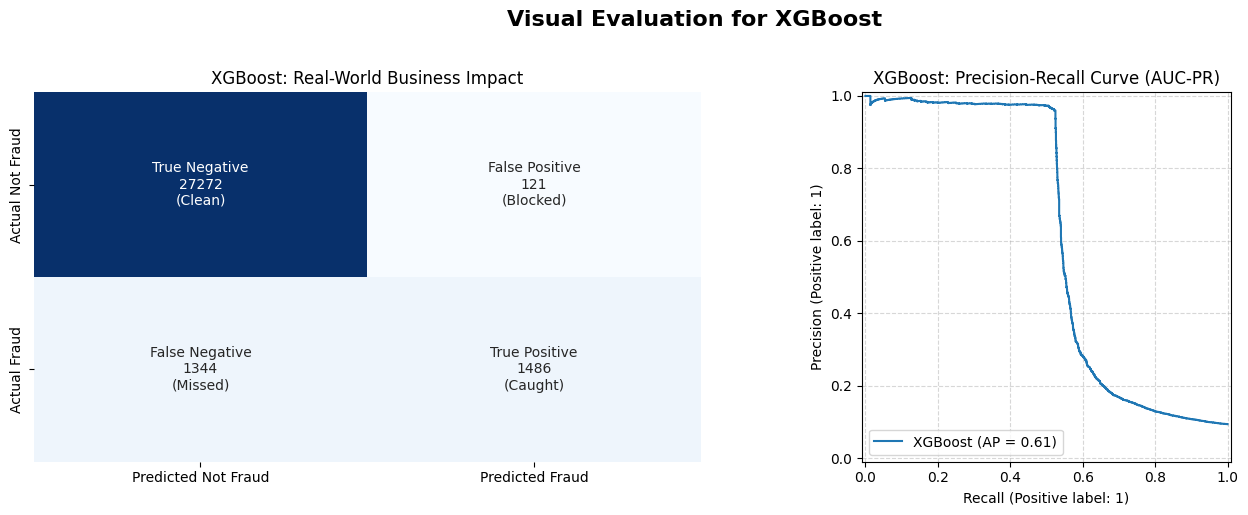

2026-06-13 15:56:12,044 - INFO - Starting Hyperparameter Tuning for LightGBM...
2026-06-13 15:57:17,467 - INFO - Best parameters for LightGBM: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300}



PERFORMANCE METRICS FOR: LIGHTGBM
The Average Precision Score:   0.6197
The F1 Score:                  0.6874
Recall (Fraud Class):          0.5240
THe True Negative (True Non-Frauds): 27391 
 The False Postives (Non-Frauds being passed as Frauds): 2 
 The False Negatives (Frauds being passed as Non-Fruads): 1347 
 The true Positives (True Fruads caught): 1483
              precision    recall  f1-score   support

   Not Fraud       0.95      1.00      0.98     27393
       Fraud       1.00      0.52      0.69      2830

    accuracy                           0.96     30223
   macro avg       0.98      0.76      0.83     30223
weighted avg       0.96      0.96      0.95     30223

--------------------------------------------------


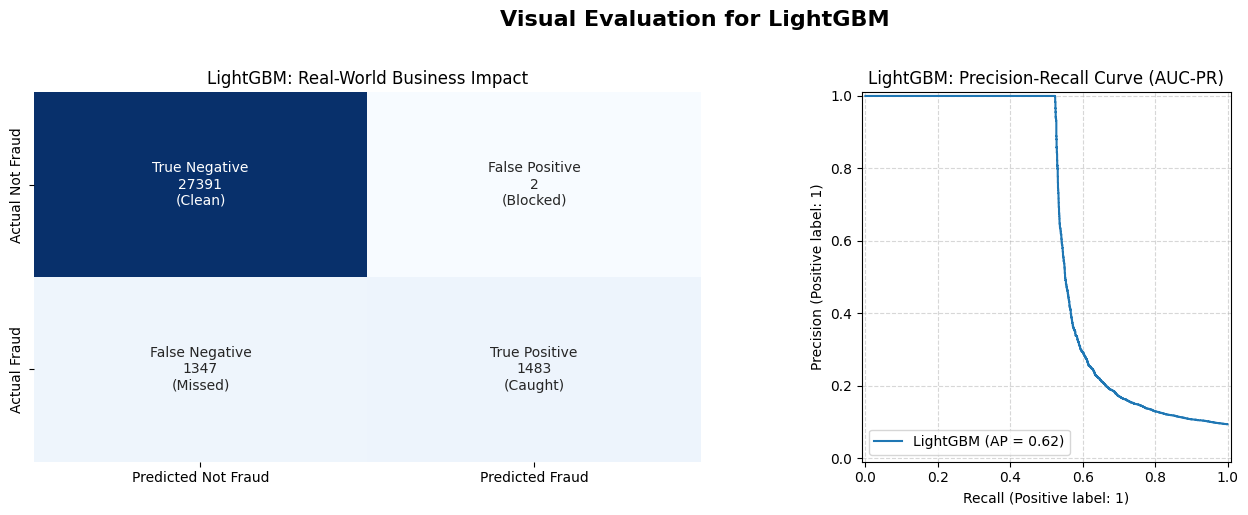

In [9]:
best_models=mt.train_and_evaluate_models()

In [10]:
mt.compare_all_models(best_models=best_models)

2026-06-13 15:57:21,762 - INFO - Running full CV comparison for Random_Forest...
2026-06-13 15:57:21,765 - INFO - Starting 5 metric Stratified K-Fold CV (k=5) for RandomForestClassifier...



MODEL COMPARISON: SIDE-BY-SIDE SUMMARY


2026-06-13 15:59:16,664 - INFO - Running full CV comparison for XGBoost...
2026-06-13 15:59:16,667 - INFO - Starting 5 metric Stratified K-Fold CV (k=5) for XGBClassifier...



CROSS-VALIDATION RESULTS for RandomForestClassifier
Average Precision        : 0.9465 ± 0.0017
Roc Auc                  : 0.9532 ± 0.0011
F1                       : 0.8602 ± 0.0026
Precision                : 0.9894 ± 0.0025
Recall                   : 0.7608 ± 0.0036

Per-fold scores:
Fold 1:
  Average Precision   : 0.9447
  Roc Auc             : 0.9520
  F1                  : 0.8608
  Precision           : 0.9864
  Recall              : 0.7635
Fold 2:
  Average Precision   : 0.9475
  Roc Auc             : 0.9539
  F1                  : 0.8613
  Precision           : 0.9924
  Recall              : 0.7609
Fold 3:
  Average Precision   : 0.9489
  Roc Auc             : 0.9548
  F1                  : 0.8632
  Precision           : 0.9923
  Recall              : 0.7639
Fold 4:
  Average Precision   : 0.9444
  Roc Auc             : 0.9518
  F1                  : 0.8553
  Precision           : 0.9880
  Recall              : 0.7540
Fold 5:
  Average Precision   : 0.9470
  Roc Auc             :

2026-06-13 15:59:39,937 - INFO - Running full CV comparison for LightGBM...
2026-06-13 15:59:39,941 - INFO - Starting 5 metric Stratified K-Fold CV (k=5) for LGBMClassifier...



CROSS-VALIDATION RESULTS for XGBClassifier
Average Precision        : 0.9571 ± 0.0013
Roc Auc                  : 0.9585 ± 0.0014
F1                       : 0.9312 ± 0.0022
Precision                : 0.9901 ± 0.0007
Recall                   : 0.8789 ± 0.0040

Per-fold scores:
Fold 1:
  Average Precision   : 0.9566
  Roc Auc             : 0.9587
  F1                  : 0.9282
  Precision           : 0.9895
  Recall              : 0.8741
Fold 2:
  Average Precision   : 0.9582
  Roc Auc             : 0.9595
  F1                  : 0.9330
  Precision           : 0.9899
  Recall              : 0.8823
Fold 3:
  Average Precision   : 0.9573
  Roc Auc             : 0.9586
  F1                  : 0.9340
  Precision           : 0.9895
  Recall              : 0.8844
Fold 4:
  Average Precision   : 0.9586
  Roc Auc             : 0.9596
  F1                  : 0.9317
  Precision           : 0.9911
  Recall              : 0.8790
Fold 5:
  Average Precision   : 0.9551
  Roc Auc             : 0.9557
 

{'Random_Forest': {'average_precision': np.float64(0.9465008717278154),
  'f1': np.float64(0.8601818376969825),
  'recall': np.float64(0.7608426371027932)},
 'XGBoost': {'average_precision': np.float64(0.9571499458562279),
  'f1': np.float64(0.9312051962783787),
  'recall': np.float64(0.8789246026394858)},
 'LightGBM': {'average_precision': np.float64(0.9585473157712492),
  'f1': np.float64(0.945872816642229),
  'recall': np.float64(0.8977986651860206)}}

In [11]:
os.makedirs("../models/fraud/", exist_ok=True)
for name, model in best_models.items(): joblib.dump(model, f"../models/fraud/{name}_final_model.pkl")

## Fraud Detection Model Comparison Report

### Executive Summary
This report compares four models trained on the **fraud_data** dataset: **Logistic Regression**, **Random Forest**, **XGBoost**, and **LightGBM**.

The dataset has a fraud rate of approximately **9.36%** (2,830 fraud cases out of 30,223 total samples), making it less severely imbalanced than typical credit card datasets. Key evaluation metrics include **Average Precision (PR-AUC)**, **F1-score**, **Precision**, **Recall**, and confusion matrix components.

**LightGBM** is the **clear recommended best model**. It delivers the highest F1-score, near-perfect precision, and dramatically fewer false positives while maintaining competitive fraud detection capability.

### Key Performance Metrics Comparison

| Model                | Avg Precision (PR-AUC) | F1-Score (Fraud) | Fraud Precision | Fraud Recall | True Positives | False Positives | False Negatives | Accuracy |
|----------------------|------------------------|------------------|-----------------|--------------|----------------|-----------------|-----------------|----------|
| **Logistic Regression** | 0.3989               | 0.2825          | 0.18           | **0.70**    | 1982          | 9219           | **848**        | 0.67    |
| **Random Forest**    | 0.6162                | 0.6712          | 0.92           | 0.5269      | 1491          | 122            | 1339           | 0.95    |
| **XGBoost**          | 0.6087                | 0.6698          | 0.92           | 0.5251      | 1486          | 121            | 1344           | 0.95    |
| **LightGBM**         | **0.6197**            | **0.6874**      | **1.00**       | 0.5240      | 1483          | **2**          | 1347           | **0.96** |

**Test Set Size**: 30,223 samples  
- **Not Fraud**: 27,393  
- **Fraud**: 2,830

### Detailed Model Analysis

#### 1. Logistic Regression
- **Strengths**: Highest fraud recall (0.70), catches more actual frauds than tree-based models.
- **Weaknesses**: Extremely poor precision (0.18), very low F1-score (0.28), and massive number of false positives (**9,219**).
- **Business Impact**: Completely impractical in production. Would overwhelm fraud teams with alerts and severely damage customer trust.

#### 2. Random Forest
- Strong precision (0.92) and decent F1-score.
- Moderate false positives (122) and misses a significant number of frauds (1,339).
- Solid baseline but outperformed by boosted models.

#### 3. XGBoost
- Very similar performance to Random Forest.
- Slightly lower F1-score and Average Precision compared to LightGBM.
- Still a strong contender with low false positives (121).

#### 4. LightGBM (Recommended)
- **Best overall model**.
- Highest Average Precision (**0.6197**) and highest F1-score (**0.6874**).
- Exceptional precision of **1.00** , virtually no false positives (only **2**).
- Maintains reasonable recall (0.52) given the strong emphasis on precision.

### Precision-Recall Tradeoff Analysis

Fraud detection always involves a critical **precision-recall tradeoff**:

- **High Recall** → Catch more fraud → Higher financial protection but increased operational cost and customer friction from false positives.
- **High Precision** → Fewer false alarms → Better customer experience and lower review costs, but risk of missing some frauds.

**Business Cost Perspective**:
- **False Negative (Missed Fraud)**: Direct revenue loss from fraudulent transactions.
- **False Positive**: Manual review labor, delayed legitimate transactions, customer dissatisfaction, potential card blocks, and support overhead.
- In this dataset, because the fraud rate is higher (~9.4%), the cost of false positives is even more pronounced.

**Logistic Regression** fails this tradeoff badly, its high recall comes at an unacceptable cost of over 9,000 false alarms.

The tree-based models achieve a far superior balance. **LightGBM** excels here by achieving **near-perfect precision** (only 2 false positives) while still detecting over half of all fraud cases. This makes it highly efficient from a business operations standpoint.

### Business Justifications & Recommendations

### Why LightGBM is the Best Choice:
1. **Minimal Operational Burden**: Only **2 false positives** dramatically reduces manual review workload compared to Random Forest/XGBoost (~120) and Logistic Regression (9,219).
2. **Maximum Precision**: A precision of 1.00 means almost every flagged transaction is actually fraudulent, high confidence in alerts.
3. **Best F1-Score**: Strongest overall balance for the fraud class.
4. **Highest Accuracy**: 0.96 on the test set.
5. **Efficiency**: LightGBM is known for fast training and inference, ideal for real-time fraud scoring.

